# v008 Vectorization — Execution Notebook

Runs the v008 mask-to-vector pipeline for a selected model checkpoint.
Set `MODEL_RUN` in the next cell to switch between checkpoint iterations.

**Output:** `outputs/vectorization/v008/{MODEL_RUN}/` — each run writes to its own subfolder and never overwrites another run.

## 1. Autoreload

In [1]:
%load_ext autoreload
%autoreload 2

## 2. Imports

In [2]:
import shutil
import sys
from pathlib import Path

import torch

_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.checkpointing import load_checkpoint
from src.models import FloorplanSegModel, build_backbone, build_decoder
from src.train_segmentation import make_preview_loader, save_sample_artifacts
from src.vectorization.run_mask_to_vector import (
    _scale_info_from_config,
    load_config,
    process_single,
)

print("Imports OK")

c:\Users\kdgki\anaconda3\envs\floorplan-cad\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 3. Run selector

Change `MODEL_RUN` to switch checkpoints.
Supported values: `"run1"`, `"run2"`.

In [3]:
MODEL_RUN = "run1"

## 4. Path configuration

In [ ]:
assert MODEL_RUN in {"run1", "run2"}, f"Unsupported MODEL_RUN: {MODEL_RUN!r}"

CHECKPOINT_PATH = PROJECT_ROOT / f"checkpoints/segformer_b0_{MODEL_RUN}/best.pt"
OUTPUT_DIR      = PROJECT_ROOT / "outputs/vectorization/v008" / MODEL_RUN
TRAIN_CONFIG    = PROJECT_ROOT / "configs/train_segformer_b0.yaml"
VECTZ_CONFIG    = PROJECT_ROOT / "configs/vectorization_v008.yaml"

IMAGE_SIZE  = 512
NUM_CLASSES = 5
N_SAMPLES   = 4

assert CHECKPOINT_PATH.exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"

print(f"MODEL_RUN       : {MODEL_RUN}")
print(f"Checkpoint      : {CHECKPOINT_PATH}")
print(f"Output dir      : {OUTPUT_DIR}")

## 5. Load vectorization config

In [5]:
vcfg       = load_config(VECTZ_CONFIG)
scale_info = _scale_info_from_config(vcfg)
print(f"Config loaded   : {VECTZ_CONFIG.name}")

Config loaded   : vectorization_v008.yaml


## 6. Load model from checkpoint

Loads decoder weights from `best.pt` only — `latest.pt` is never used.

In [6]:
device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backbone = build_backbone(variant="segformer_b0", pretrained=True)
decoder  = build_decoder(variant="segformer_b0", num_classes=NUM_CLASSES, output_size=IMAGE_SIZE)

payload = load_checkpoint(CHECKPOINT_PATH, decoder, device=device)
print(f"arch_version    : {payload.get('arch_version')}")
print(f"epoch           : {payload.get('epoch')}")
print(f"best metric     : {payload.get('best_metric_name')} = {payload.get('best_metric_value', 0.0):.4f}")

model = FloorplanSegModel(backbone=backbone, decoder=decoder)
model.eval().to(device)
print("Model ready.")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 192/192 [00:00<00:00, 32003.59it/s]


[transformers] SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


arch_version    : v2_custom_decoder
epoch           : 47
best metric     : val_mIoU = 0.8337
Model ready.


## 7. Load preview sample set

Uses the first `N_SAMPLES` entries from `splits/val.json` (same set as training epoch previews).

In [7]:
loader = make_preview_loader(TRAIN_CONFIG, n_samples=N_SAMPLES)
print(f"Preview loader  : {N_SAMPLES} samples from val split")

Preview loader  : 4 samples from val split

## 8. Generate CNN predictions — save input.png and prediction.png

In [ ]:
# Only this run's subfolder is cleared; other run folders are untouched.
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

prediction_paths = save_sample_artifacts(
    model, loader, device, OUTPUT_DIR, n_samples=N_SAMPLES
)

for p in prediction_paths:
    print(f"  {p.relative_to(PROJECT_ROOT)}")

## 9. Run v008 vectorization — save vector.svg

In [9]:
for pred_path in prediction_paths:
    sample_dir = pred_path.parent
    process_single(pred_path, vcfg, scale_info, sample_dir, output_filename="vector.svg")

print(f"\nVectorization complete — {len(prediction_paths)} SVG files written.")

  Processing: prediction.png
    walls=29, doors=4, windows=4, rooms=3, unresolved=1
    -> C:\Users\kdgki\Desktop\MSCDP\Projects\neural_floorplan\outputs\vectorization\v008\sample_000\vector.svg
  Processing: prediction.png


    walls=61, doors=16, windows=11, rooms=14, unresolved=7
    -> C:\Users\kdgki\Desktop\MSCDP\Projects\neural_floorplan\outputs\vectorization\v008\sample_001\vector.svg
  Processing: prediction.png


    walls=54, doors=20, windows=31, rooms=12, unresolved=0
    -> C:\Users\kdgki\Desktop\MSCDP\Projects\neural_floorplan\outputs\vectorization\v008\sample_002\vector.svg
  Processing: prediction.png
    walls=44, doors=9, windows=1, rooms=7, unresolved=1
    -> C:\Users\kdgki\Desktop\MSCDP\Projects\neural_floorplan\outputs\vectorization\v008\sample_003\vector.svg

Vectorization complete — 4 SVG files written.


## 10. Verify output structure

In [10]:
expected = ["input.png", "prediction.png", "vector.svg"]
all_ok   = True

for i in range(N_SAMPLES):
    sample_dir = OUTPUT_DIR / f"sample_{i:03d}"
    statuses   = []
    for name in expected:
        ok = (sample_dir / name).exists()
        if not ok:
            all_ok = False
        statuses.append(f"{name}:{'OK' if ok else 'MISSING'}")
    print(f"  sample_{i:03d}  |  {' | '.join(statuses)}")

print()
print("All artifacts present." if all_ok else "WARNING: some artifacts are missing.")

  sample_000  |  input.png:OK | prediction.png:OK | vector.svg:OK
  sample_001  |  input.png:OK | prediction.png:OK | vector.svg:OK
  sample_002  |  input.png:OK | prediction.png:OK | vector.svg:OK
  sample_003  |  input.png:OK | prediction.png:OK | vector.svg:OK

All artifacts present.


## 11. Visual comparison

`input.png → prediction.png` grid, then inline SVG outputs.

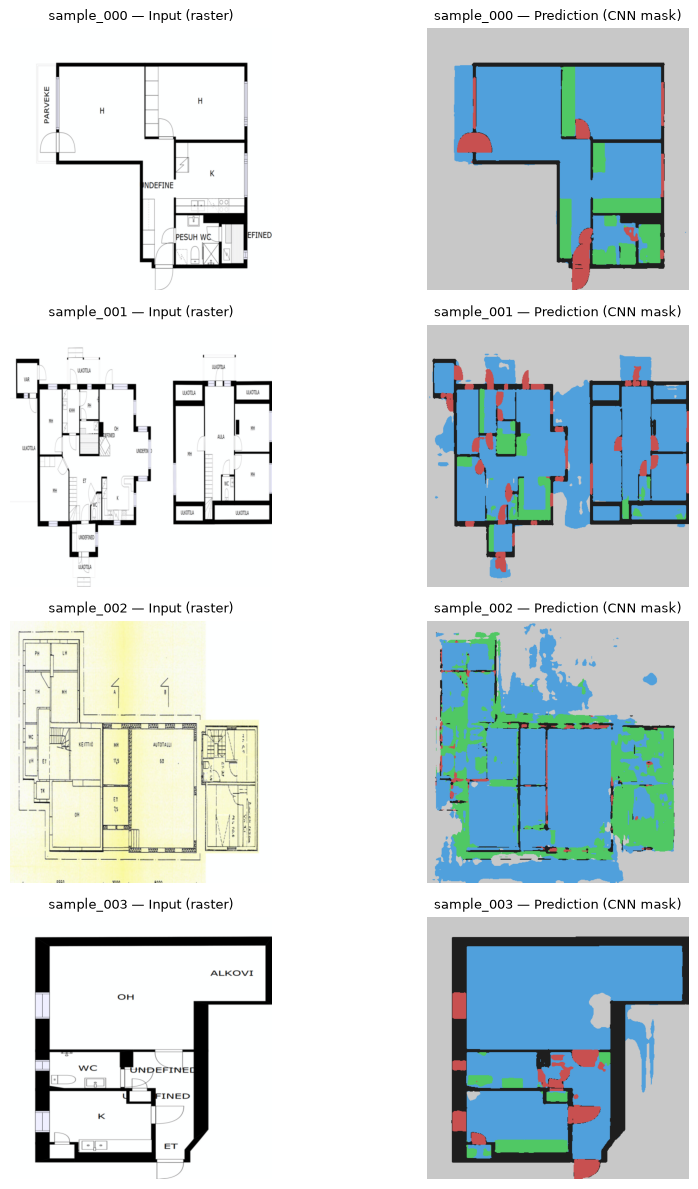


Vector SVG outputs:
  sample_000: C:\Users\kdgki\Desktop\MSCDP\Projects\neural_floorplan\outputs\vectorization\v008\sample_000\vector.svg


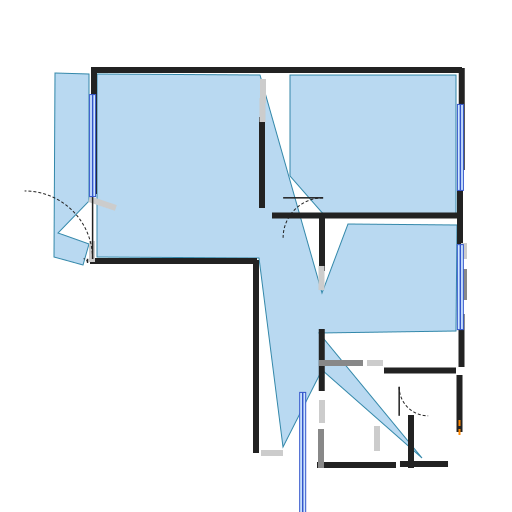

  sample_001: C:\Users\kdgki\Desktop\MSCDP\Projects\neural_floorplan\outputs\vectorization\v008\sample_001\vector.svg


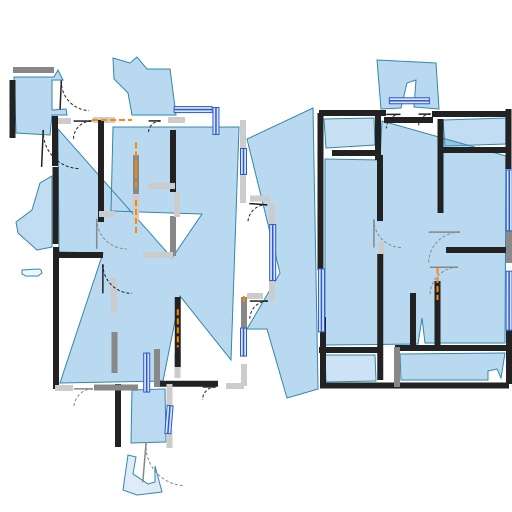

  sample_002: C:\Users\kdgki\Desktop\MSCDP\Projects\neural_floorplan\outputs\vectorization\v008\sample_002\vector.svg


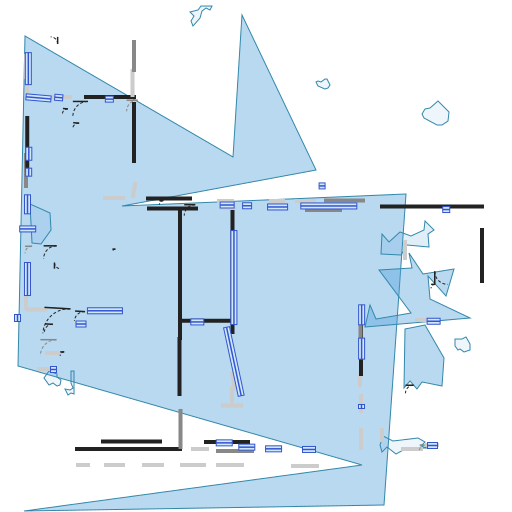

  sample_003: C:\Users\kdgki\Desktop\MSCDP\Projects\neural_floorplan\outputs\vectorization\v008\sample_003\vector.svg


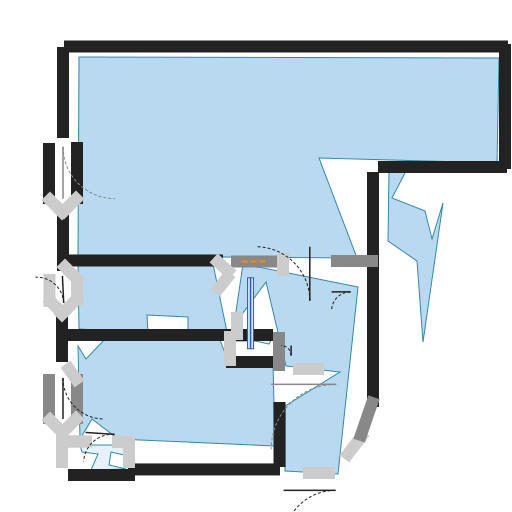

In [11]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from IPython.display import SVG, display

fig, axes = plt.subplots(N_SAMPLES, 2, figsize=(10, 3 * N_SAMPLES))
col_labels = ["Input (raster)", "Prediction (CNN mask)"]

for i in range(N_SAMPLES):
    sample_dir = OUTPUT_DIR / f"sample_{i:03d}"
    for j, fname in enumerate(["input.png", "prediction.png"]):
        ax = axes[i][j]
        p  = sample_dir / fname
        if p.exists():
            ax.imshow(mpimg.imread(str(p)))
        ax.set_title(f"sample_{i:03d} — {col_labels[j]}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()

print("\nVector SVG outputs:")
for i in range(N_SAMPLES):
    svg_path = OUTPUT_DIR / f"sample_{i:03d}" / "vector.svg"
    if svg_path.exists():
        print(f"  sample_{i:03d}: {svg_path}")
        display(SVG(filename=str(svg_path)))